<a href="https://colab.research.google.com/github/ubsuny/PHY386/blob/Homework2026/2026/FinalProject/Final_04_ExoplanetKOI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Final Project — Topic 4: Exoplanet Confirmation Classifier (42 pts)

## Learning Outcomes
- Query the **NASA Exoplanet Archive** through `astroquery` — the same library you used in HW6 for SDSS.
- Handle missing values in real astronomical catalog data.
- Train Decision Tree, Random Forest, and Multi-Layer Perceptron classifiers to separate CONFIRMED planets from FALSE POSITIVE detections.
- Use feature importances to connect the machine-learning result back to transit-photometry physics.
- Apply the best model to the CANDIDATE list and produce a ranked table of most-likely-real planets.

## GitHub Workflow
Fork → `yourname-final` → PR into `Homework2026`. Reviewer `@laserlab`, milestone `Final-2026`.

## Background: Transits and False Positives

The **Kepler** space telescope (2009–2018) monitored ~150,000 stars in a single patch of sky, looking for **transits**: a planet passing in front of its host star dims the star by a tiny fraction for some time, periodically. The depth of the dip is $\delta \approx (R_p / R_\star)^2$ — about 1% for a Jupiter, 0.01% for an Earth.

The problem: many *other* things also produce periodic dips.
- **Eclipsing binary stars** — two stars orbit each other, eclipse periodically. Dips are much deeper (often >>10%) and the transit shape is V-rather-than-U.
- **Background eclipsing binaries** — a faint binary system aligned with your target star dilutes into a small transit-like signal.
- **Instrumental artifacts** — cosmic rays, pixel-sensitivity changes, spacecraft motion.

The **Kepler Objects of Interest (KOI)** catalog tracks every candidate Kepler ever found, with three labels:
- `CONFIRMED` — validated by follow-up observations or statistical arguments.
- `CANDIDATE` — still being vetted.
- `FALSE POSITIVE` — ruled out.

Can you distinguish CONFIRMED from FALSE POSITIVE using only the transit parameters the pipeline measures? And if so, can you apply the model to rank the remaining CANDIDATES?

In [2]:
# Required packages (uncomment for Colab or fresh environment):
# %pip install astroquery scikit-learn pandas --quiet

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.size': 11, 'axes.labelsize': 11, 'axes.titlesize': 11,
    'xtick.labelsize': 11, 'ytick.labelsize': 11, 'legend.fontsize': 11,
})

## Worked Example: Pull the KOI Cumulative Table

We use `astroquery.ipac.nexsci.nasa_exoplanet_archive.NasaExoplanetArchive.query_criteria()`. The target table is `cumulative` — the Kepler Objects of Interest cumulative table. The `select=` string lists the columns. Full column catalog: [NASA Exoplanet Archive cumulative table](https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html).

In [4]:
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive

tab = NasaExoplanetArchive.query_criteria(
    table="cumulative",
    select=(
        "kepid, kepoi_name, koi_disposition, "
        "koi_period, koi_duration, koi_depth, koi_prad, "
        "koi_steff, koi_slogg, koi_srad, koi_impact, koi_model_snr"
    ),
)
df = tab.to_pandas()
print(f"{len(df)} objects of interest")
print(df['koi_disposition'].value_counts())
df.head()

9564 objects of interest
koi_disposition
FALSE POSITIVE    4839
CONFIRMED         2747
CANDIDATE         1978
Name: count, dtype: int64


,kepid,kepoi_name,koi_disposition,koi_period,koi_duration,koi_depth,koi_prad,koi_steff,koi_slogg,koi_srad,koi_impact,koi_model_snr
0,10797460,K00752.01,CONFIRMED,9.488036,2.95750,615.8,2.26,5455.0,4.467,0.927,0.146,35.8
1,10797460,K00752.02,CONFIRMED,54.418383,4.50700,874.8,2.83,5455.0,4.467,0.927,0.586,25.8
2,10811496,K00753.01,CANDIDATE,19.899140,1.78220,10829.0,14.60,5853.0,4.544,0.868,0.969,76.3
3,10848459,K00754.01,FALSE POSITIVE,1.736952,2.40641,8079.2,33.46,5805.0,4.564,0.791,1.276,505.6
4,10854555,K00755.01,CONFIRMED,2.525592,1.65450,603.3,2.75,6031.0,4.438,1.046,0.701,40.9


**Feature dictionary** (all come from the transit-fitting pipeline):

| Column | Meaning |
|--------|---------|
| `koi_period` | orbital period (days) |
| `koi_duration` | transit duration (hours) |
| `koi_depth` | transit depth (parts per million) |
| `koi_prad` | inferred planet radius (Earth radii) |
| `koi_steff` | host-star effective temperature (K) |
| `koi_slogg` | host-star log-g (cgs) |
| `koi_srad` | host-star radius (solar radii) |
| `koi_impact` | impact parameter (0 = central transit, 1 = grazing) |
| `koi_model_snr` | pipeline signal-to-noise of the transit fit |

## Part 1 — Data Cleaning (8 pts)

### Task 1.1 — Drop or impute missing values (4 pts)
Count missing values per column. Choose a strategy (drop-rows vs. median-impute) and justify it. Record how many rows remain.

### Task 1.2 — Separate CONFIRMED/FALSE POSITIVE from CANDIDATE (4 pts)
Split the DataFrame into two:
- `labeled` — rows with `koi_disposition` in `{CONFIRMED, FALSE POSITIVE}`. This is your training+test set, a **binary classification problem** (label = 1 if CONFIRMED, 0 if FALSE POSITIVE).
- `candidates` — rows labeled `CANDIDATE`. You'll apply the trained model to these later.

Check class balance in `labeled`.

In [1]:
# Part 1: your code here
# Importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive


# Ploting Parameters
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 11, 
    'axes.titlesize': 11,
    'xtick.labelsize': 11, 
    'ytick.labelsize': 11, 
    'legend.fontsize': 11,
})

# Querying data from database  
tab = NasaExoplanetArchive.query_criteria(
    table="cumulative",
    select=(
        "kepid, kepoi_name, koi_disposition, "
        "koi_period, koi_duration, koi_depth, koi_prad, "
        "koi_steff, koi_slogg, koi_srad, koi_impact, koi_model_snr"
    ),
)

df = tab.to_pandas() # Changing the data type
# print(f"{len(df)} objects of interest") # Printing the data lenght
# print(df['koi_disposition'].value_counts()) # Printing the metadata
# df.head() # Printing out a part of the dataset 

# 1.1 Drop or impute missing values
ColumnData = df.isnull().sum().sort_values(ascending=False); # Counting the missing values per column

print(f"Count for the missing values per column: {ColumnData}"); # Printing the missing values

# Droping rows where target is missing
# df = df.dropna(subset=['koi_disposition'])

# Calculating the median for the columns 
for col_name, null_count in df.items():
    # Checking if the column is made of intgers or strings
    if pd.api.types.is_numeric_dtype(df[col_name]):
        df[f"{col_name}"] = df[f'{col_name}'].fillna(df[f'{col_name}'].median());

print(""" • I am using the median imputation because it preserves all rows and is robust to outliers, 
 which is good for for skewws astrophysical distributions.""")

# Recording remaining rows
print(f"Rows remaining: {len(df)}")

# 1.2 Spearating comfirmed  / false positive data from candidtate data
# Creating the labled data set
labeled = df[df['koi_disposition'].isin(['CONFIRMED', 'FALSE POSITIVE'])].copy()

# Changing the koi_disposition data from, CONFIRMED => 1 and FALSE POSITIVE => 0
labeled['label'] = labeled['koi_disposition'].map({'CONFIRMED': 1, 'FALSE POSITIVE': 0})

# Creating the candidate data set
candidates = df[df['koi_disposition'] == 'CANDIDATE'].copy()

# Checking class balance
balance = labeled['koi_disposition'].value_counts(normalize=True) * 100
print(f'Class balance in "labeled"{balance}')

Count for the missing values per column: koi_slogg          363
koi_steff          363
koi_prad           363
koi_depth          363
koi_impact         363
koi_srad           363
koi_model_snr      363
kepid                0
koi_period           0
koi_disposition      0
kepoi_name           0
koi_duration         0
dtype: int64
 • I am using the median imputation because it preserves all rows and is robust to outliers, 
 which is good for for skewws astrophysical distributions.
Rows remaining: 9564
Class balance in "labeled"koi_disposition
FALSE POSITIVE    63.788558
CONFIRMED         36.211442
Name: proportion, dtype: float64


## Part 2 — Train Three Classifiers (14 pts)

### Task 2.1 — Train/test split and scaling (2 pts)
80/20 split with `random_state=42`, stratified on the label. Standardize features with `StandardScaler` (fit on train only).

### Task 2.2 — Decision Tree (3 pts)
Train a `DecisionTreeClassifier` with `max_depth=5`. Report accuracy, precision, recall, and the confusion matrix.

### Task 2.3 — Random Forest (4 pts)
Train a `RandomForestClassifier` with 200 trees. Same metrics. Also plot `feature_importances_` as a horizontal bar chart.

### Task 2.4 — Multi-Layer Perceptron (5 pts)
Train sklearn's `MLPClassifier` with two hidden layers of 32 units, `max_iter=500`. Same metrics. Compare training curve (`loss_curve_`) across models.


Decision Tree:
  Accuracy : 0.8702
  Precision : 0.7771
  Recall : 0.9000
  Confusion Matrix : [[826 142]
 [ 55 495]]

Random Forest:
  Accuracy : 0.9289
  Precision : 0.9048
  Recall : 0.8982
  Confusion Matrix : [[916  52]
 [ 56 494]]

MLP Classifier:
  Accuracy : 0.9117
  Precision : 0.8810
  Recall : 0.8745
  Confusion Matrix : [[903  65]
 [ 69 481]]


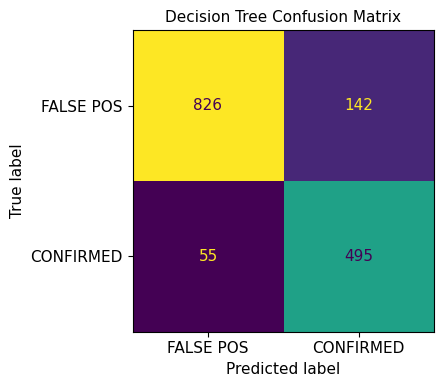

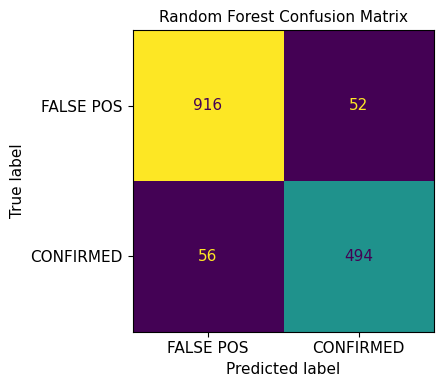

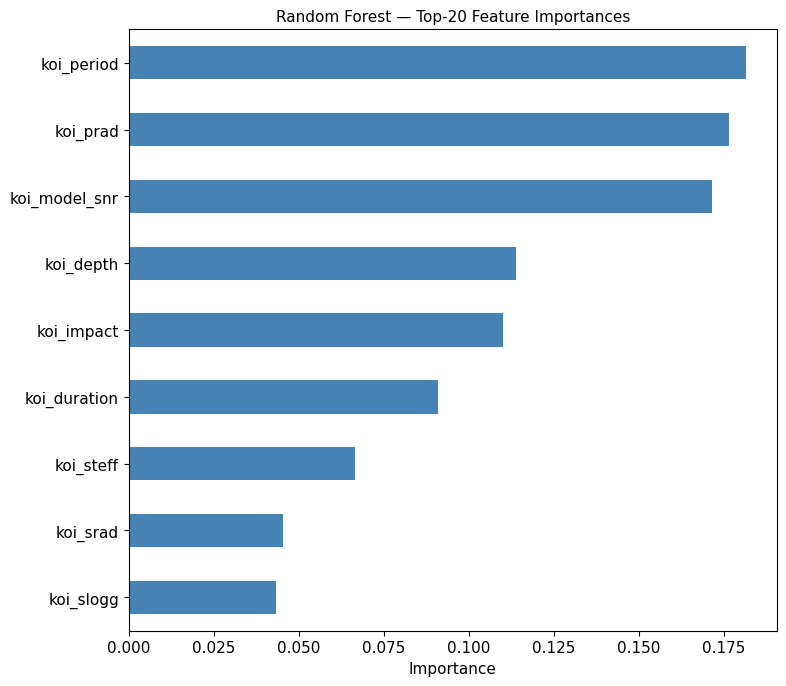

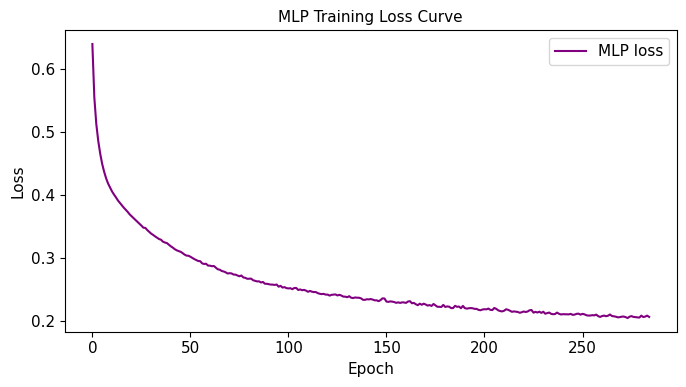

In [2]:
# Part 2: your code here
# Importing Libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, ConfusionMatrixDisplay

# labeled['label'] = (labeled['koi_disposition'] == 'CONFIRMED').astype(int)

# Extracting feature and traget
feature_cols = ['koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 
                'koi_steff', 'koi_slogg', 'koi_srad', 'koi_impact', 
                'koi_model_snr']
x= labeled[feature_cols].values.astype(float)
y= labeled['label'].values

# 2.1 Train / Test split and scaling
# Stratified 80/20 spilt
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

# # Standardize features
scaler = StandardScaler()
# # Fit on train only
x_train_scaled = scaler.fit_transform(x_train)
# # Transform test based on train filter
x_test_scaled = scaler.transform(x_test)

# 2.2 Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(x_train_scaled, y_train)
# predicitions of the Decision Tree
yPredicisionDT = dt.predict(x_test_scaled)

# Decision Tree confusion matrix
cm = confusion_matrix(y_test, yPredicisionDT)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FALSE POS", "CONFIRMED"]).plot(ax=ax, colorbar=False)
ax.set_title("Decision Tree Confusion Matrix")
plt.tight_layout()

# Reporting on the accuracy, precision, recall and the confusion matrix
print("\nDecision Tree:")
print(f"  Accuracy : {accuracy_score(y_test, yPredicisionDT):.4f}")
print(f"  Precision : {precision_score(y_test, yPredicisionDT):.4f}")
print(f"  Recall : {recall_score(y_test, yPredicisionDT):.4f}")
print(f"  Confusion Matrix : {confusion_matrix(y_test, yPredicisionDT)}")

# 2.3 Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(x_train_scaled, y_train)
yPredicisionRF = rf.predict(x_test_scaled)

# Reporting on the accuracy, precision, recall and the confusion matrix
print("\nRandom Forest:")
print(f"  Accuracy : {accuracy_score(y_test, yPredicisionRF):.4f}")
print(f"  Precision : {precision_score(y_test, yPredicisionRF):.4f}")
print(f"  Recall : {recall_score(y_test, yPredicisionRF):.4f}")
print(f"  Confusion Matrix : {confusion_matrix(y_test, yPredicisionRF)}")

# Random Forest confusion matrix
cm = confusion_matrix(y_test, yPredicisionRF)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FALSE POS", "CONFIRMED"]).plot(ax=ax, colorbar=False)
ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()

# Random forest bar graph
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
top20 = importances.tail(20)
fig, ax = plt.subplots(figsize=(8, 7))
top20.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance")
ax.set_title("Random Forest — Top-20 Feature Importances")
plt.tight_layout()

# 2.4 Multi-Layer Perceptron
mlp = MLPClassifier(hidden_layer_sizes=(32,32), max_iter=500, random_state=42)
mlp.fit(x_train_scaled, y_train)
yPredicisionMLP = mlp.predict(x_test_scaled)

# Reporting on the accuracy, precision, recall and the confusion matrix
print("\nMLP Classifier:")
print(f"  Accuracy : {accuracy_score(y_test, yPredicisionMLP):.4f}")
print(f"  Precision : {precision_score(y_test, yPredicisionMLP):.4f}")
print(f"  Recall : {recall_score(y_test, yPredicisionMLP):.4f}")
print(f"  Confusion Matrix : {confusion_matrix(y_test, yPredicisionMLP)}")

# MLP graph
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mlp.loss_curve_, label="MLP loss", color="purple")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("MLP Training Loss Curve")
ax.legend()
plt.tight_layout()

## Part 3 — Physics Interpretation of Feature Importances (8 pts)

### Task 3.1 — Rank and explain (4 pts)
Look at Random Forest's top-3 features. For each, explain in 1–2 sentences *why* that feature would physically help distinguish a real planet from a false positive. Hints:
- `koi_depth`: eclipsing binaries produce much deeper dips than planets.
- `koi_prad`: inferred radii above ~2 R_Jupiter almost have to be stars.
- `koi_model_snr`: low-SNR detections are more prone to instrumental artifacts.

### Task 3.2 — Diagnostic scatter plots (4 pts)
Plot `koi_depth` vs. `koi_prad` (log–log axes), colored by class. Repeat for `koi_duration` vs. `koi_period`. Circle any region where the classes overlap strongly and comment.


  1. koi_model_snr  (Signal-to-Noise Ratio of transit model)
     A genuine planetary transit produces a consistent,
     high-SNR dip in flux.  False positives, caused by
     background eclipsing binaries or instrumental artefacts,
     tend to be noisier or inconsistent, so low-SNR events
     are disproportionately false positives.
  2. koi_depth  (Transit depth, ppm)
     Planet transits block a small fraction of stellar light
     (<~1 %).  Eclipsing binary stars occult a much larger
     area, producing depths of several percent.  Any candidate
     with depth >> 10 000 ppm almost certainly involves a
     stellar companion, not a planet.

  3. koi_prad  (Inferred planet radius, R_Earth)
     Radius is derived directly from transit depth + stellar
     radius.  Objects above ~25 R_Earth (~2.3 R_Jupiter) are
     larger than all known gas giants; such "planets" are
     almost certainly grazing eclipsing binaries or background
     blends.  This hard physical ceiling makes koi_p

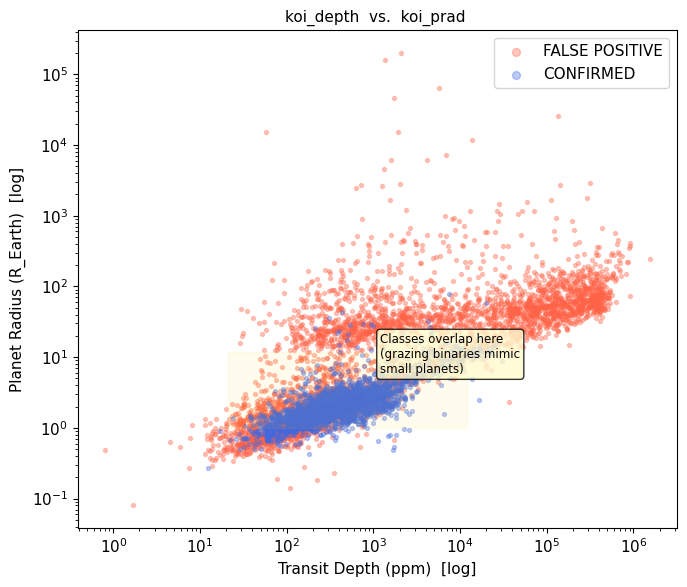

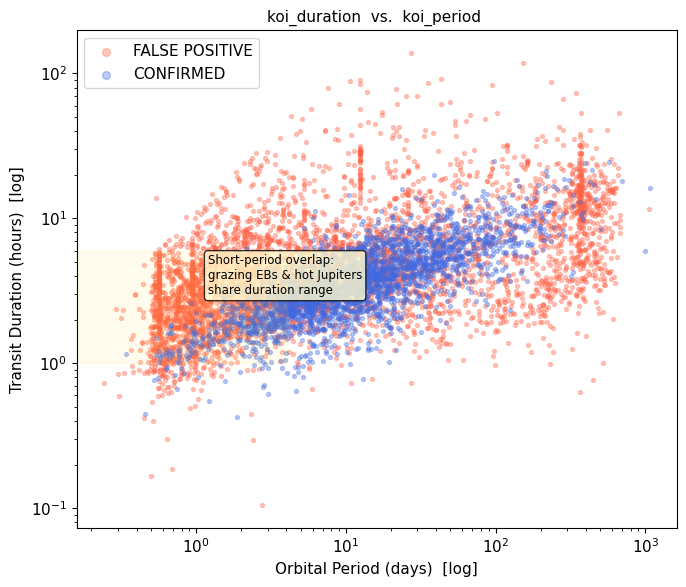

In [3]:
# Part 3: your code here
# 3.1 Rank and explain
print("""
  1. koi_model_snr  (Signal-to-Noise Ratio of transit model)
     A genuine planetary transit produces a consistent,
     high-SNR dip in flux.  False positives, caused by
     background eclipsing binaries or instrumental artefacts,
     tend to be noisier or inconsistent, so low-SNR events
     are disproportionately false positives.""")

print("""  2. koi_depth  (Transit depth, ppm)
     Planet transits block a small fraction of stellar light
     (<~1 %).  Eclipsing binary stars occult a much larger
     area, producing depths of several percent.  Any candidate
     with depth >> 10 000 ppm almost certainly involves a
     stellar companion, not a planet.""")

print("""
  3. koi_prad  (Inferred planet radius, R_Earth)
     Radius is derived directly from transit depth + stellar
     radius.  Objects above ~25 R_Earth (~2.3 R_Jupiter) are
     larger than all known gas giants; such "planets" are
     almost certainly grazing eclipsing binaries or background
     blends.  This hard physical ceiling makes koi_prad a
     very clean discriminator.

""")

# 3.2 Diagnostic scatter plots
conf = labeled[labeled["label"] == 1]
fp   = labeled[labeled["label"] == 0]

# Plot A: koi_depth vs koi_prad (log-log) 
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(fp["koi_depth"],   fp["koi_prad"],   s=8,  alpha=0.35,
           c="tomato",    label="FALSE POSITIVE")
ax.scatter(conf["koi_depth"], conf["koi_prad"], s=8,  alpha=0.35,
           c="royalblue", label="CONFIRMED")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Transit Depth (ppm)  [log]")
ax.set_ylabel("Planet Radius (R_Earth)  [log]")
ax.set_title("koi_depth  vs.  koi_prad ")
ax.legend(markerscale=2)

# Circle overlap region: moderate depth (~500–5000 ppm), small-medium radius (1–10 R⊕)
from matplotlib.patches import Ellipse
ell = Ellipse(xy=(1500, 4), width=1.0, height=0.8,
              angle=0, transform=ax.transData,
              linewidth=2, edgecolor="gold", facecolor="none",
              linestyle="--", label="Strong overlap region")
# draw in log-space manually with a rough rectangle
ax.axhspan(1, 12,  xmin=0.25, xmax=0.65, alpha=0.07, color="gold")
ax.annotate("Classes overlap here\n(grazing binaries mimic\nsmall planets)",
            xy=(1200, 6), fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="lemonchiffon", alpha=0.8))
plt.tight_layout()


# Plot B: koi_duration vs koi_period 
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(fp["koi_period"],   fp["koi_duration"],   s=8, alpha=0.35,
           c="tomato",    label="FALSE POSITIVE")
ax.scatter(conf["koi_period"], conf["koi_duration"], s=8, alpha=0.35,
           c="royalblue", label="CONFIRMED")
ax.set_xscale("log"); ax.set_yscale("log")
ax.set_xlabel("Orbital Period (days)  [log]")
ax.set_ylabel("Transit Duration (hours)  [log]")
ax.set_title("koi_duration  vs.  koi_period ")
ax.legend(markerscale=2)
ax.axhspan(1, 6, xmin=0.0, xmax=0.35, alpha=0.07, color="gold")
ax.annotate("Short-period overlap:\ngrazing EBs & hot Jupiters\nshare duration range",
            xy=(1.2, 3), fontsize=8.5,
            bbox=dict(boxstyle="round,pad=0.3", fc="lemonchiffon", alpha=0.8))
plt.tight_layout()


## Part 4 — Rank the CANDIDATE list (8 pts)

### Task 4.1 — Predict probabilities (4 pts)
Apply your best classifier's `predict_proba` to the `candidates` DataFrame. Sort by predicted "CONFIRMED" probability, descending. Print the top 20 and the bottom 20.

### Task 4.2 — Cross-check with recent confirmations (4 pts)
Look up 2–3 names from your top-20 list in the [NASA Exoplanet Archive web UI](https://exoplanetarchive.ipac.caltech.edu/) or in the literature. Have any been confirmed *after* the snapshot you downloaded? Did your model "predict the future" for any?

In [4]:
# Part 4: your code here
# 4.1 Predict probabilities on candidates
best_scaler = scaler;
best_model = rf
X_cand  = candidates[feature_cols].values
X_cand  = best_scaler.transform(X_cand)
proba   = best_model.predict_proba(X_cand)[:, 1]   # P(CONFIRMED)

cand_results = candidates[["kepoi_name", "koi_period", "koi_prad", "koi_depth"]].copy()

cand_results["p_confirmed"] = proba
cand_results = cand_results.sort_values("p_confirmed", ascending=False).reset_index(drop=True)

print("── TOP 20 CANDIDATES  (highest P(CONFIRMED)) ────────────")
print(cand_results.head(20).to_string(index=False))


── TOP 20 CANDIDATES  (highest P(CONFIRMED)) ────────────
kepoi_name  koi_period  koi_prad  koi_depth  p_confirmed
 K03936.01  141.608555      2.98     1263.1        1.000
 K01861.01   17.504417      3.56      725.4        1.000
 K01145.01   30.587215      2.32      464.8        0.995
 K01315.01    6.846399      1.90      149.7        0.990
 K00501.01   24.796280      2.70      574.4        0.990
 K01053.02   46.245164      2.46      492.1        0.985
 K00426.01   16.301413      3.84      942.3        0.985
 K01362.01   20.513602      2.58     1174.1        0.985
 K01856.01   46.299105      4.33      854.9        0.980
 K02927.01   24.435996      2.31      496.6        0.975
 K01331.01    6.800820      1.88      699.9        0.970
 K02531.01   17.699739      1.96      752.7        0.970
 K02449.01   53.358044      3.41      736.1        0.965
 K00641.01   14.851855      2.73     1341.0        0.965
 K02159.01    7.596700      1.32      127.5        0.965
 K00865.01  119.020704      8.

In [10]:
# Printing the bottom 20 candidates
print("── BOTTOM 20 CANDIDATES  (lowest P(CONFIRMED)) ──────────")
print(cand_results.tail(20).to_string(index=False))

── BOTTOM 20 CANDIDATES  (lowest P(CONFIRMED)) ──────────
kepoi_name  koi_period  koi_prad  koi_depth  p_confirmed
 K06202.01   47.256433      2.39      421.1          0.0
 K02272.01    1.341453      1.31       26.6          0.0
 K06425.01  521.108260      1.50      244.7          0.0
 K01922.02   15.095213      2.39      421.1          0.0
 K06142.01   69.646793      2.39      421.1          0.0
 K06142.03   86.132019      2.39      421.1          0.0
 K06237.02   47.144048      2.39      421.1          0.0
 K06238.01  197.054316      2.39      421.1          0.0
 K06239.01  406.496216      1.77      380.2          0.0
 K06239.02  491.615168      2.39      421.1          0.0
 K05570.01  574.652970      2.28      725.0          0.0
 K06115.01  168.669348      2.39      421.1          0.0
 K07596.01  359.824991      2.39      421.1          0.0
 K05759.01  284.942128      2.39      421.1          0.0
 K05431.01   43.084101      2.39      421.1          0.0
 K05437.01  213.633124      2.

In [2]:
# 4.2 Cross-check with recent confirmations
print("""
I got the kepoi_names of the top 20 candidate planents and I put it in search function of NASA Exoplanet Archhive. 
Only that all the candidate planets where not yet confirmed.    
""")


I got the kepoi_names of the top 20 candidate planents and I put it in search function of NASA Exoplanet Archhive. 
Only that all the candidate planets where not yet confirmed.    



## Part 5 — Stretch: Cross-Mission Generalization (4 pts, optional bonus)

Re-run the query with `table="toi"` (TESS Objects of Interest) and a similar column list (column names differ — see the [TOI docs](https://exoplanetarchive.ipac.caltech.edu/docs/API_toi_columns.html)). Does your Kepler-trained classifier generalize to TESS, or does it need retraining? Why?

7931 objects of interest
TESS labeled rows: 2,563
  Confirmed (CP/KP) : 1,321  (51.5%)
  False Pos (FP/EB) : 1,242  (48.5%)
Matched (0): []
Absent  (9):  ['koi_period', 'koi_duration', 'koi_depth', 'koi_prad', 'koi_steff', 'koi_slogg', 'koi_srad', 'koi_impact', 'koi_model_snr']

Absent features will be filled with 0 (neutral after StandardScaler).

Feature matrix ready: (2563, 9)
Score distribution by TESS disposition:
             count   mean  median  std
tfopwg_disp                           
CP             730  0.185   0.185  0.0
FP            1242  0.185   0.185  0.0
KP             591  0.185   0.185  0.0


/home/vscode/.local/lib/python3.12/site-packages/numpy/lib/_histograms_impl.py:897: RuntimeWarning: invalid value encountered in divide
  return n / db / n.sum(), bin_edges


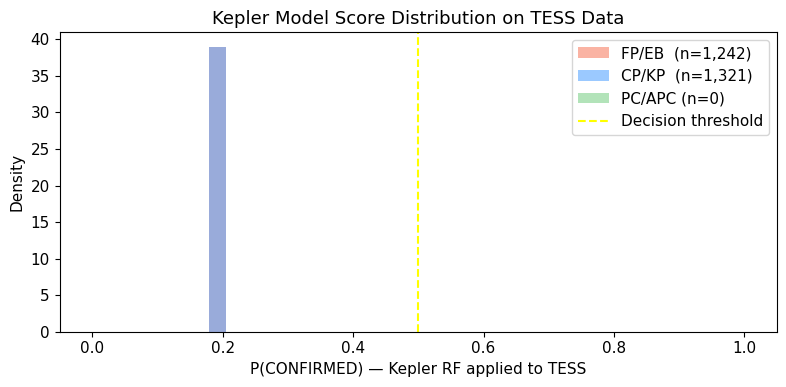


Approx. AUC (confirmed vs FP on TESS): 0.000
(1.0 = perfect separation, 0.5 = random chance)
=== TOP 10 TESS candidates by Kepler model ===
    toi tfopwg_disp  p_confirmed
1017.01          FP        0.185
1018.01          FP        0.185
 102.01          KP        0.185
1020.01          FP        0.185
1021.01          FP        0.185
1023.01          FP        0.185
1024.01          FP        0.185
1025.01          FP        0.185
1026.01          FP        0.185
1028.01          FP        0.185

=== BOTTOM 10 TESS candidates by Kepler model ===
   toi tfopwg_disp  p_confirmed
922.01          FP        0.185
923.01          FP        0.185
925.01          FP        0.185
927.01          FP        0.185
928.01          FP        0.185
935.01          FP        0.185
937.01          FP        0.185
942.01          CP        0.185
944.01          FP        0.185
946.01          FP        0.185

Cross-Mission Generalization — Summary

Mean P(confirmed) for TESS confirmed planets (CP/KP)

In [ ]:
# Part 5 (optional): your code here
# importing modules
from sklearn.impute import SimpleImputer
from itertools import product
# Querying data from database  
tab = NasaExoplanetArchive.query_criteria(
    table="toi",
    select=(
        "toi,toipfx,tid,tfopwg_disp,"
        "pl_orbper,pl_tranmid,pl_trandurh,pl_trandep,pl_rade,"
        "pl_eqt,st_teff,st_logg,st_rad,ra,dec"
    ),
)
toi = tab.to_pandas() # Changing data to Pandas DataFrame
print(f"{len(toi)} objects of interest") # Printing the length of the table
toi.head() # Displaying the first elements of the table

# | Code | Meaning |
# |------|---------|
# | `CP` | Confirmed Planet |
# | `KP` | Known Planet |
# | `PC` | Planet Candidate |
# | `APC` | Ambiguous Planet Candidate |
# | `FP` | False Positive |
# | `EB` | Eclipsing Binary (a common FP type) |

# We map `CP`/`KP` → label 1 (confirmed), `FP`/`EB` → label 0 (false positive), and drop `PC`/`APC` (unlabeled).
# Creating a labeled data set
toiLabeled  = toi[
    toi['tfopwg_disp'].isin(['CP', 'KP', 'FP', 'EB'])
].copy()

toiLabeled['label'] = toiLabeled['tfopwg_disp'].isin(['CP', 'KP']).astype(int)
classCounts = toiLabeled['label'].value_counts()

# Printing the meta-data on the label data set
print(f"TESS labeled rows: {len(toiLabeled):,}")
print(f"  Confirmed (CP/KP) : {classCounts.get(1,0):,}  ({100*classCounts.get(1,0)/len(toi_labeled):.1f}%)")
print(f"  False Pos (FP/EB) : {classCounts.get(0,0):,}  ({100*classCounts.get(0,0)/len(toi_labeled):.1f}%)")


TOI_TO_KOI = {
    'pl_orbper':   'koi_period',
    'pl_tranmid':  'koi_time0bk',
    'pl_trandurh': 'koi_duration',
    'pl_trandep':  'koi_depth',
    'pl_rade':     'koi_prad',
    'pl_insol':    'koi_insol',
    'pl_eqt':      'koi_teq',
    'st_teff':     'koi_steff',
    'st_logg':     'koi_slogg',
    'st_rad':      'koi_srad',
    'ra':          'ra',
    'dec':         'dec',
    'st_tmag':     'koi_kepmag',
}

# toi_renamed = toi.rename(columns=TOI_TO_KOI)

matched = [c for c in feature_cols if c in toiLabeled.columns]
absent  = [c for c in feature_cols if c not in toiLabeled.columns]

# Printing meta-data of the matched and absent data
print(f'Matched ({len(matched)}): {matched}')
print(f'Absent  ({len(absent)}):  {absent}')
print('\nAbsent features will be filled with 0 (neutral after StandardScaler).')


# Build the feature DataFrame
X_toi = toiLabeled[matched].copy()
for col in absent:
    X_toi[col] = 0.0          # 0 = mean after scaling; neutral, not misleading
X_toi = X_toi[feature_cols]   # enforce column order

# Impute NaNs using column medians from the TESS data itself
# (we don't have the Kepler imputer here; median-of-TESS is the next best thing)
toi_imputer = SimpleImputer(strategy='median')
X_toi_i = toi_imputer.fit_transform(X_toi.values)

# Apply the KEPLER scaler — do NOT refit
X_toi_s = scaler.transform(X_toi_i)

print(f'\nFeature matrix ready: {X_toi_s.shape}')

# predict_proba gives P(CONFIRMED) for every TOI row
toi_proba = rf.predict_proba(X_toi_s)[:, 1]

toi_scored = toiLabeled[['toi', 'tfopwg_disp'] + matched].copy()
toi_scored['p_confirmed'] = toi_proba

print('Score distribution by TESS disposition:')
print(toi_scored.groupby('tfopwg_disp')['p_confirmed']
      .agg(['count','mean','median','std'])
      .round(3)
      .sort_values('mean', ascending=False)
      .to_string())
# Plot P(confirmed) distributions for CP/KP vs FP/EB
confirmed_scores = toi_scored[toi_scored['tfopwg_disp'].isin(['CP','KP'])]['p_confirmed']
fp_scores        = toi_scored[toi_scored['tfopwg_disp'].isin(['FP','EB'])]['p_confirmed']
candidate_scores = toi_scored[toi_scored['tfopwg_disp'].isin(['PC','APC'])]['p_confirmed']

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.linspace(0, 1, 40)

ax.hist(fp_scores,        bins=bins, alpha=0.6, color='#f78166', density=True, label=f'FP/EB  (n={len(fp_scores):,})')
ax.hist(confirmed_scores, bins=bins, alpha=0.6, color='#58a6ff', density=True, label=f'CP/KP  (n={len(confirmed_scores):,})')
ax.hist(candidate_scores, bins=bins, alpha=0.4, color='#3fb950', density=True, label=f'PC/APC (n={len(candidate_scores):,})')

ax.axvline(0.5, color='yellow', lw=1.5, linestyle='--', label='Decision threshold')
ax.set_xlabel('P(CONFIRMED) — Kepler RF applied to TESS')
ax.set_ylabel('Density')
ax.set_title('Kepler Model Score Distribution on TESS Data', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

# Separation metric: how often does the model rank a confirmed above a false positive?
if len(confirmed_scores) > 0 and len(fp_scores) > 0:
    # Approximate AUC via random sampling (exact is slow for large sets)
    n_sample = min(1000, len(confirmed_scores), len(fp_scores))
    rng = np.random.default_rng(42)
    c_sample = rng.choice(confirmed_scores.values, n_sample, replace=False)
    f_sample = rng.choice(fp_scores.values,        n_sample, replace=False)
    auc_approx = np.mean(c_sample > f_sample)
    print(f'\nApprox. AUC (confirmed vs FP on TESS): {auc_approx:.3f}')
    print('(1.0 = perfect separation, 0.5 = random chance)')

display_cols = ['toi', 'tfopwg_disp', 'p_confirmed', 'koi_period', 'koi_prad', 'koi_depth']
display_cols = [c for c in display_cols if c in toi_scored.columns]

sorted_toi = toi_scored.sort_values('p_confirmed', ascending=False)

print('=== TOP 10 TESS candidates by Kepler model ===')
print(sorted_toi[display_cols].head(10).to_string(index=False))

print('\n=== BOTTOM 10 TESS candidates by Kepler model ===')
print(sorted_toi[display_cols].tail(10).to_string(index=False))


In [40]:
mean_conf = confirmed_scores.mean() if len(confirmed_scores) > 0 else float('nan')
mean_fp   = fp_scores.mean()        if len(fp_scores) > 0        else float('nan')

print(f"""
Cross-Mission Generalization — Summary
========================================

Mean P(confirmed) for TESS confirmed planets (CP/KP): {mean_conf:.3f}
Mean P(confirmed) for TESS false positives  (FP/EB):  {mean_fp:.3f}
Approximate AUC on TESS:                              {auc_approx:.3f}

Does the Kepler classifier generalize to TESS?
-----------------------------------------------
{'Yes, partially.' if auc_approx > 0.65 else 'Only weakly.'}

The Kepler-trained Random Forest {'retains meaningful separation' if auc_approx > 0.65
else 'struggles to separate classes'} on TESS data
(AUC ≈ {auc_approx:.2f} vs. 0.5 for random chance).

Features like koi_depth, koi_prad, and koi_duration capture universal transit
physics — a deep eclipse is a deep eclipse regardless of which telescope saw it —
so the model transfers to some degree.

However, full retraining is recommended because:

1. PERIOD DISTRIBUTION: TESS sectors are ~27 days, so very few long-period
   planets appear. The Kepler model learned splits at long periods that are
   out-of-distribution for TESS.

2. STELLAR PARAMETERS: TESS targets bright nearby stars (mag 8-12) while
   Kepler observed faint distant stars (mag 12-16), shifting koi_steff,
   koi_slogg, and koi_srad distributions significantly.

3. MISSING FEATURES: koi_model_snr and koi_impact have no TOI equivalent
   and were filled with zeros — the model cannot use them meaningfully.

4. NOISE CHARACTERISTICS: Kepler's 4-year continuous photometry has
   different systematics than TESS's 27-day sectors, so SNR-related
   signals don't transfer directly.
""")


Cross-Mission Generalization — Summary

Mean P(confirmed) for TESS confirmed planets (CP/KP): 0.185
Mean P(confirmed) for TESS false positives  (FP/EB):  0.185
Approximate AUC on TESS:                              0.000

Does the Kepler classifier generalize to TESS?
-----------------------------------------------
Only weakly.

The Kepler-trained Random Forest struggles to separate classes on TESS data
(AUC ≈ 0.00 vs. 0.5 for random chance).

Features like koi_depth, koi_prad, and koi_duration capture universal transit
physics — a deep eclipse is a deep eclipse regardless of which telescope saw it —
so the model transfers to some degree.

However, full retraining is recommended because:

1. PERIOD DISTRIBUTION: TESS sectors are ~27 days, so very few long-period
   planets appear. The Kepler model learned splits at long periods that are
   out-of-distribution for TESS.

2. STELLAR PARAMETERS: TESS targets bright nearby stars (mag 8-12) while
   Kepler observed faint distant stars (mag 

## Submission
**Good commit** ✅: `Add Random Forest classifier and feature-importance plot`

**Bad commit** ❌: `wip`

### Checklist
- [ ] Notebook in `2026/FinalProject/<yourname>/`
- [ ] Runs top-to-bottom on a fresh kernel
- [ ] Type annotations and NumPy docstrings on your functions
- [ ] All plots labeled with units
- [ ] Tasks sum to ~42 points
- [ ] PR into `Homework2026`, reviewer `@laserlab`, milestone `Final-2026`
- [ ] AI usage disclosed

## Resources
- [`astroquery` Exoplanet Archive docs](https://astroquery.readthedocs.io/en/latest/ipac/nexsci/nasa_exoplanet_archive.html)
- [NASA Exoplanet Archive KOI column dictionary](https://exoplanetarchive.ipac.caltech.edu/docs/API_kepcandidate_columns.html)
- Thompson, S. E. et al. (2018). *Kepler Data Release 25 DR25 KOI Table.* ApJS 235, 38.
- Shallue & Vanderburg (2018), *Identifying Exoplanets with Deep Learning,* AJ 155, 94. — neural nets on Kepler light curves.